Tour Konser

In [41]:
import re
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)

raw_path = Path(r"C:\Users\Fahrul Rozi\Downloads\Dataset\my_file (1).csv")
clean_path = Path(r"C:\Users\Fahrul Rozi\Downloads\DataScience\my_file_clean.csv")

df_raw = pd.read_csv(raw_path)
df_raw.head()

,Rank,Peak,All Time Peak,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
0,1,1,2,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,2,1,7[2],"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,3,1[4],2[5],"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,4,2[7],10[7],"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,5,2[4],NaN,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]


In [42]:
def clean_column_name(name):
    return (
        name.replace("\u00a0", " ")
        .strip()
        .lower()
        .replace("(in 2022 dollars)", "2022_usd")
        .replace(".", "")
        .replace(" ", "_")
    )


def parse_money(value):
    if pd.isna(value):
        return pd.NA

    digits = re.sub(r"[^0-9]", "", str(value))
    return int(digits) if digits else pd.NA


def parse_number(value):
    if pd.isna(value):
        return pd.NA

    match = re.search(r"\d+", str(value))
    return int(match.group()) if match else pd.NA


def clean_tour_title(value):
    if pd.isna(value):
        return value

    cleaned = re.sub(r"\[[^\]]+\]", "", str(value))
    cleaned = re.sub(r"[\u2020\u2021*]", "", cleaned)
    return re.sub(r"\s+", " ", cleaned).strip()


df_clean = df_raw.copy()
df_clean.columns = [clean_column_name(col) for col in df_clean.columns]

df_clean = df_clean.rename(
    columns={
        "actual_gross": "actual_gross_usd",
        "adjusted_gross_2022_usd": "adjusted_gross_2022_usd",
        "average_gross": "average_gross_usd",
        "year(s)": "year_range",
        "ref": "references",
    }
)

money_columns = ["actual_gross_usd", "adjusted_gross_2022_usd", "average_gross_usd"]
for column in money_columns:
    df_clean[column] = df_clean[column].apply(parse_money).astype("Int64")

for column in ["peak", "all_time_peak"]:
    df_clean[column] = df_clean[column].apply(parse_number).astype("Int64")

year_parts = df_clean["year_range"].str.extract(r"(?P<start_year>\d{4})(?:\D+(?P<end_year>\d{4}))?")
df_clean["start_year"] = year_parts["start_year"].astype("Int64")
df_clean["end_year"] = year_parts["end_year"].fillna(year_parts["start_year"]).astype("Int64")
df_clean["duration_years"] = df_clean["end_year"] - df_clean["start_year"] + 1

df_clean["tour_title"] = df_clean["tour_title"].apply(clean_tour_title)
df_clean["artist"] = df_clean["artist"].str.strip()
df_clean["references"] = df_clean["references"].astype("string").str.strip()
df_clean["shows"] = df_clean["shows"].astype("Int64")

df_clean = df_clean.drop(columns=["peak", "all_time_peak", "references"])
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

df_clean.head()

,rank,actual_gross_usd,adjusted_gross_2022_usd,artist,tour_title,year_range,shows,average_gross_usd,start_year,end_year,duration_years
0,1,780000000,780000000,Taylor Swift,The Eras Tour,2023–2024,56,13928571,2023,2024,2
1,2,579800000,579800000,Beyoncé,Renaissance World Tour,2023,56,10353571,2023,2023,1
2,3,411000000,560622615,Madonna,Sticky & Sweet Tour,2008–2009,85,4835294,2008,2009,2
3,4,397300000,454751555,Pink,Beautiful Trauma World Tour,2018–2019,156,2546795,2018,2019,2
4,5,345675146,402844849,Taylor Swift,Reputation Stadium Tour,2018,53,6522173,2018,2018,1


In [43]:
quality_check = pd.DataFrame(
    {
        "dtype": df_clean.dtypes.astype(str),
        "missing_values": df_clean.isna().sum(),
        "unique_values": df_clean.nunique(dropna=True),
    }
)

print(f"Jumlah baris duplikat: {df_clean.duplicated().sum()}")
quality_check

Jumlah baris duplikat: 0


,dtype,missing_values,unique_values
rank,int64,0,19
actual_gross_usd,Int64,0,20
adjusted_gross_2022_usd,Int64,0,20
artist,str,0,9
tour_title,str,0,20
year_range,str,0,16
shows,Int64,0,18
average_gross_usd,Int64,0,20
start_year,Int64,0,11
end_year,Int64,0,14


In [44]:
try:
    df_clean.to_csv(clean_path, index=False)
    print(f"Data bersih tersimpan di: {clean_path}")
except PermissionError:
    backup_path = clean_path.with_name(f"{clean_path.stem}_baru{clean_path.suffix}")
    df_clean.to_csv(backup_path, index=False)
    print(f"File lama sedang terbuka, jadi data bersih tersimpan di: {backup_path}")

Data bersih tersimpan di: C:\Users\Fahrul Rozi\Downloads\DataScience\my_file_clean.csv


## Exploratory Data Analysis


In [45]:
import matplotlib.pyplot as plt
from IPython.display import display

dropped_clean_path = Path(r"C:\Users\Fahrul Rozi\Downloads\DataScience\my_file_clean_baru.csv")
eda_path = dropped_clean_path if dropped_clean_path.exists() else clean_path

df_eda = pd.read_csv(eda_path)

print(f"Data EDA dibaca dari: {eda_path}")
print(f"Jumlah baris: {df_eda.shape[0]}")
print(f"Jumlah kolom: {df_eda.shape[1]}")
df_eda.head()

Data EDA dibaca dari: C:\Users\Fahrul Rozi\Downloads\DataScience\my_file_clean_baru.csv
Jumlah baris: 20
Jumlah kolom: 11


,rank,actual_gross_usd,adjusted_gross_2022_usd,artist,tour_title,year_range,shows,average_gross_usd,start_year,end_year,duration_years
0,1,780000000,780000000,Taylor Swift,The Eras Tour,2023–2024,56,13928571,2023,2024,2
1,2,579800000,579800000,Beyoncé,Renaissance World Tour,2023,56,10353571,2023,2023,1
2,3,411000000,560622615,Madonna,Sticky & Sweet Tour,2008–2009,85,4835294,2008,2009,2
3,4,397300000,454751555,Pink,Beautiful Trauma World Tour,2018–2019,156,2546795,2018,2019,2
4,5,345675146,402844849,Taylor Swift,Reputation Stadium Tour,2018,53,6522173,2018,2018,1


## Feature Engineering Sederhana

Bagian ini membuat kolom tambahan untuk membantu analisis: gross per show, selisih gross setelah penyesuaian inflasi, dan kategori gross.

In [46]:
df_eda["gross_per_show"] = df_eda["actual_gross_usd"] / df_eda["shows"]
df_eda["gross_difference"] = df_eda["adjusted_gross_2022_usd"] - df_eda["actual_gross_usd"]

df_eda["gross_category"] = pd.cut(
    df_eda["actual_gross_usd"],
    bins=[-float("inf"), 200_000_000, 400_000_000, float("inf")],
    labels=["Low", "Medium", "High"],
)

feature_path = Path(r"C:\Users\Fahrul Rozi\Downloads\DataScience\my_file_feature_engineered.csv")
df_eda.to_csv(feature_path, index=False)

print(f"Data dengan feature engineering tersimpan di: {feature_path}")
df_eda[["artist", "tour_title", "actual_gross_usd", "shows", "gross_per_show", "gross_difference", "gross_category"]].head()

Data dengan feature engineering tersimpan di: C:\Users\Fahrul Rozi\Downloads\DataScience\my_file_feature_engineered.csv


,artist,tour_title,actual_gross_usd,shows,gross_per_show,gross_difference,gross_category
0,Taylor Swift,The Eras Tour,780000000,56,1.392857e+07,0,High
1,Beyoncé,Renaissance World Tour,579800000,56,1.035357e+07,0,High
2,Madonna,Sticky & Sweet Tour,411000000,85,4.835294e+06,149622615,High
3,Pink,Beautiful Trauma World Tour,397300000,156,2.546795e+06,57451555,Medium
4,Taylor Swift,Reputation Stadium Tour,345675146,53,6.522173e+06,57169703,Medium


In [47]:
eda_quality = pd.DataFrame(
    {
        "dtype": df_eda.dtypes.astype(str),
        "missing_values": df_eda.isna().sum(),
        "unique_values": df_eda.nunique(dropna=True),
    }
)

print(f"Jumlah data duplikat: {df_eda.duplicated().sum()}")
eda_quality

Jumlah data duplikat: 0


,dtype,missing_values,unique_values
rank,int64,0,19
actual_gross_usd,int64,0,20
adjusted_gross_2022_usd,int64,0,20
artist,str,0,9
tour_title,str,0,20
year_range,str,0,16
shows,int64,0,18
average_gross_usd,int64,0,20
start_year,int64,0,11
end_year,int64,0,14


In [48]:
numeric_columns = [
    "rank",
    "actual_gross_usd",
    "adjusted_gross_2022_usd",
    "shows",
    "average_gross_usd",
    "start_year",
    "end_year",
    "duration_years",
    "gross_per_show",
    "gross_difference",
]

df_eda[numeric_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
rank,20.0,1.045000e+01,5.942488e+00,1.000000e+00,5.750000e+00,1.050000e+01,1.525000e+01,2.000000e+01
actual_gross_usd,20.0,2.879509e+08,1.563284e+08,1.500000e+08,1.915000e+08,2.397500e+08,3.152876e+08,7.800000e+08
adjusted_gross_2022_usd,20.0,3.438781e+08,1.514627e+08,1.854231e+08,2.457557e+08,2.974889e+08,3.924451e+08,7.800000e+08
shows,20.0,1.100000e+02,6.650762e+01,4.100000e+01,5.900000e+01,8.700000e+01,1.345000e+02,3.250000e+02
average_gross_usd,20.0,3.726571e+06,3.393340e+06,6.153850e+05,1.647508e+06,2.342100e+06,4.933024e+06,1.392857e+07
start_year,20.0,2.013850e+03,5.622090e+00,2.002000e+03,2.011250e+03,2.013500e+03,2.016500e+03,2.023000e+03
end_year,20.0,2.014700e+03,5.332127e+00,2.005000e+03,2.011750e+03,2.014500e+03,2.017250e+03,2.024000e+03
duration_years,20.0,1.850000e+00,7.451598e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00
gross_per_show,20.0,3.726670e+06,3.393260e+06,6.153846e+05,1.647508e+06,2.342100e+06,4.933024e+06,1.392857e+07
gross_difference,20.0,5.592719e+07,3.673729e+07,0.000000e+00,3.713159e+07,5.513837e+07,7.188114e+07,1.496226e+08


In [49]:
top_gross_tours = df_eda.sort_values("actual_gross_usd", ascending=False).head(10)
top_average_gross_tours = df_eda.sort_values("average_gross_usd", ascending=False).head(10)

display(top_gross_tours[["artist", "tour_title", "actual_gross_usd", "shows", "year_range"]])
display(top_average_gross_tours[["artist", "tour_title", "average_gross_usd", "shows", "year_range"]])

,artist,tour_title,actual_gross_usd,shows,year_range
0,Taylor Swift,The Eras Tour,780000000,56,2023–2024
1,Beyoncé,Renaissance World Tour,579800000,56,2023
2,Madonna,Sticky & Sweet Tour,411000000,85,2008–2009
3,Pink,Beautiful Trauma World Tour,397300000,156,2018–2019
4,Taylor Swift,Reputation Stadium Tour,345675146,53,2018
5,Madonna,The MDNA Tour,305158363,88,2012
6,Celine Dion,Taking Chances World Tour,280000000,131,2008–2009
7,Pink,Summer Carnival,257600000,41,2023–2024
8,Beyoncé,The Formation World Tour,256084556,49,2016
9,Taylor Swift,The 1989 World Tour,250400000,85,2015


,artist,tour_title,average_gross_usd,shows,year_range
0,Taylor Swift,The Eras Tour,13928571,56,2023–2024
1,Beyoncé,Renaissance World Tour,10353571,56,2023
4,Taylor Swift,Reputation Stadium Tour,6522173,53,2018
7,Pink,Summer Carnival,6282927,41,2023–2024
8,Beyoncé,The Formation World Tour,5226215,49,2016
2,Madonna,Sticky & Sweet Tour,4835294,85,2008–2009
5,Madonna,The MDNA Tour,3467709,88,2012
14,Madonna,Confessions Tour,3233333,60,2006
9,Taylor Swift,The 1989 World Tour,2945882,85,2015
3,Pink,Beautiful Trauma World Tour,2546795,156,2018–2019


In [50]:
artist_summary = (
    df_eda.groupby("artist", as_index=False)
    .agg(
        total_tours=("tour_title", "count"),
        total_actual_gross_usd=("actual_gross_usd", "sum"),
        avg_actual_gross_usd=("actual_gross_usd", "mean"),
        avg_gross_per_show_usd=("average_gross_usd", "mean"),
        total_shows=("shows", "sum"),
    )
    .sort_values("total_actual_gross_usd", ascending=False)
)

artist_summary

,artist,total_tours,total_actual_gross_usd,avg_actual_gross_usd,avg_gross_per_show_usd,total_shows
8,Taylor Swift,4,1526075146,3.815188e+08,6.285203e+06,280
6,Madonna,4,1079958363,2.699896e+08,3.401767e+06,315
1,Beyoncé,3,1064984556,3.549949e+08,5.771797e+06,237
7,Pink,3,838900000,2.796333e+08,3.375166e+06,339
5,Lady Gaga,2,397400000,1.987000e+08,1.426460e+06,301
2,Celine Dion,1,280000000,2.800000e+08,2.137405e+06,131
4,Katy Perry,1,204000000,2.040000e+08,1.350993e+06,151
3,Cher,1,200000000,2.000000e+08,6.153850e+05,325
0,Adele,1,167700000,1.677000e+08,1.385950e+06,121


In [51]:
year_summary = (
    df_eda.groupby("start_year", as_index=False)
    .agg(
        total_tours=("tour_title", "count"),
        total_actual_gross_usd=("actual_gross_usd", "sum"),
        avg_actual_gross_usd=("actual_gross_usd", "mean"),
    )
    .sort_values("start_year")
)

year_summary

,start_year,total_tours,total_actual_gross_usd,avg_actual_gross_usd
0,2002,1,200000000,2.000000e+08
1,2006,1,194000000,1.940000e+08
2,2008,2,691000000,3.455000e+08
3,2009,1,227400000,2.274000e+08
4,2012,2,475158363,2.375792e+08
5,2013,3,563100000,1.877000e+08
6,2014,1,204000000,2.040000e+08
7,2015,2,420200000,2.101000e+08
8,2016,2,423784556,2.118923e+08
9,2018,2,742975146,3.714876e+08


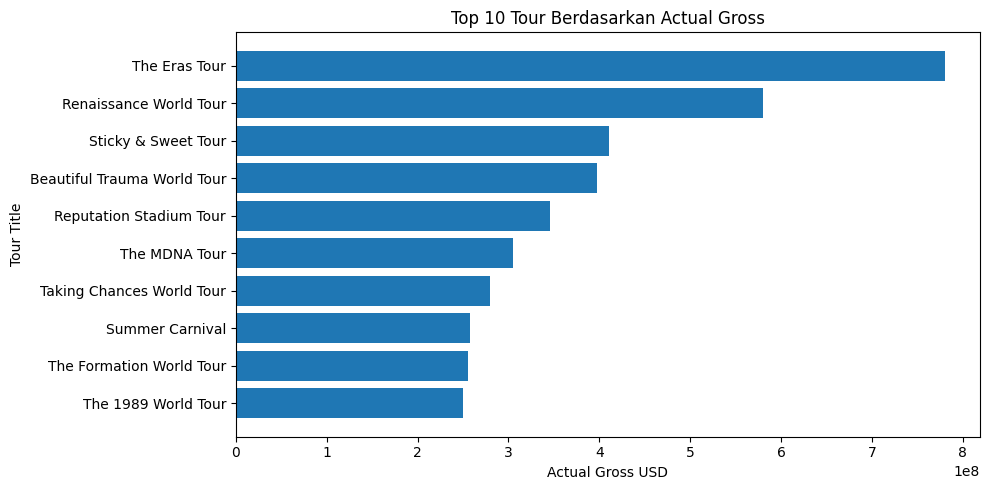

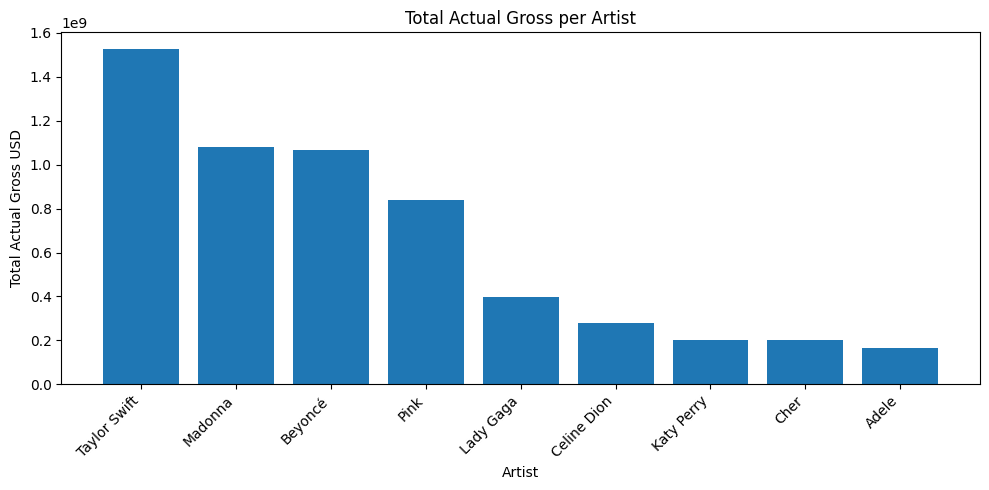

In [52]:
plt.figure(figsize=(10, 5))
plt.barh(top_gross_tours["tour_title"], top_gross_tours["actual_gross_usd"])
plt.gca().invert_yaxis()
plt.title("Top 10 Tour Berdasarkan Actual Gross")
plt.xlabel("Actual Gross USD")
plt.ylabel("Tour Title")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(artist_summary["artist"], artist_summary["total_actual_gross_usd"])
plt.title("Total Actual Gross per Artist")
plt.xlabel("Artist")
plt.ylabel("Total Actual Gross USD")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

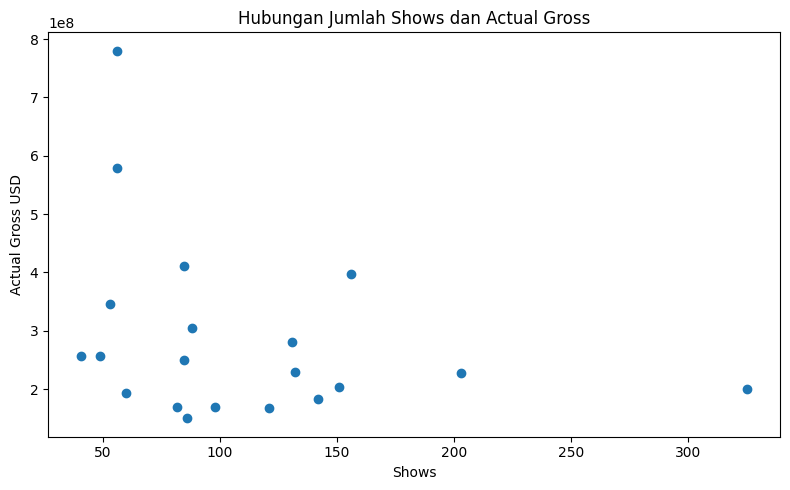

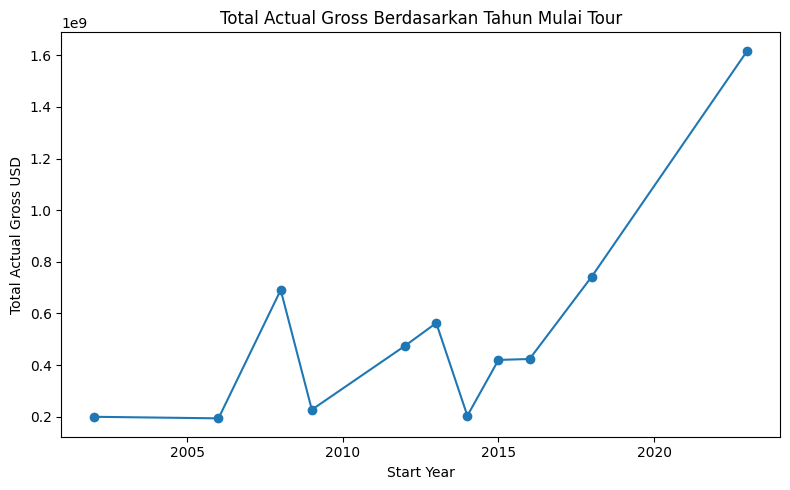

In [53]:
plt.figure(figsize=(8, 5))
plt.scatter(df_eda["shows"], df_eda["actual_gross_usd"])
plt.title("Hubungan Jumlah Shows dan Actual Gross")
plt.xlabel("Shows")
plt.ylabel("Actual Gross USD")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(year_summary["start_year"], year_summary["total_actual_gross_usd"], marker="o")
plt.title("Total Actual Gross Berdasarkan Tahun Mulai Tour")
plt.xlabel("Start Year")
plt.ylabel("Total Actual Gross USD")
plt.tight_layout()
plt.show()

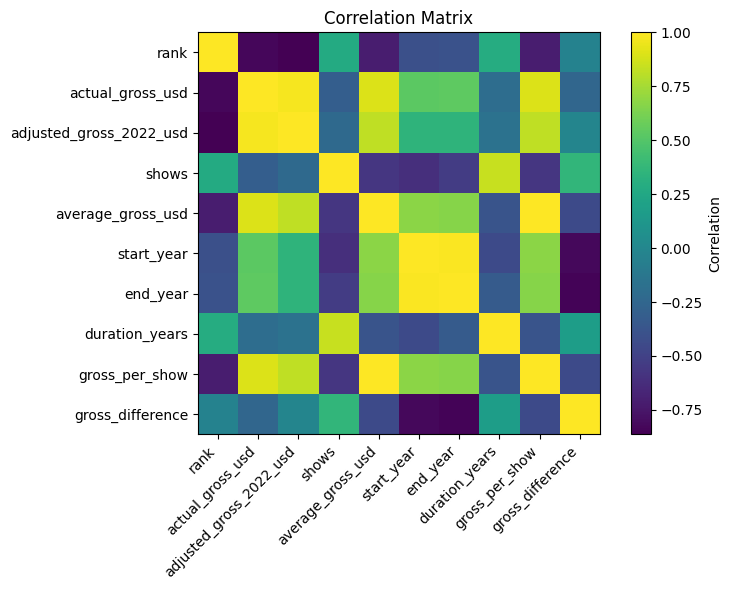

,rank,actual_gross_usd,adjusted_gross_2022_usd,shows,average_gross_usd,start_year,end_year,duration_years,gross_per_show,gross_difference
rank,1.000000,-0.827226,-0.863114,0.276861,-0.717166,-0.409043,-0.390840,0.289419,-0.717174,-0.038398
actual_gross_usd,-0.827226,1.000000,0.972000,-0.305908,0.899649,0.533668,0.534916,-0.198737,0.899659,-0.247886
adjusted_gross_2022_usd,-0.863114,0.972000,1.000000,-0.227223,0.821066,0.351453,0.347864,-0.162446,0.821076,-0.013299
shows,0.276861,-0.305908,-0.227223,1.000000,-0.568995,-0.615541,-0.531470,0.841106,-0.568966,0.364926
average_gross_usd,-0.717166,0.899649,0.821066,-0.568995,1.000000,0.675696,0.659441,-0.379247,1.000000,-0.443143
start_year,-0.409043,0.533668,0.351453,-0.615541,0.675696,1.000000,0.992141,-0.445364,0.675685,-0.821930
end_year,-0.390840,0.534916,0.347864,-0.531470,0.659441,0.992141,1.000000,-0.329834,0.659435,-0.842039
duration_years,0.289419,-0.198737,-0.162446,0.841106,-0.379247,-0.445364,-0.329834,1.000000,-0.379209,0.175943
gross_per_show,-0.717174,0.899659,0.821076,-0.568966,1.000000,0.675685,0.659435,-0.379209,1.000000,-0.443143
gross_difference,-0.038398,-0.247886,-0.013299,0.364926,-0.443143,-0.821930,-0.842039,0.175943,-0.443143,1.000000


In [54]:
correlation_matrix = df_eda[numeric_columns].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="viridis")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

correlation_matrix

## Data Visualization: Memahami Cerita Data

Visualisasi di bawah fokus pada pertanyaan utama: tur mana yang menghasilkan uang paling besar, artist mana yang paling dominan, dan apakah jumlah show berhubungan dengan total gross.

In [55]:
from matplotlib.ticker import FuncFormatter

def usd_millions(value, position=None):
    return f"${value / 1_000_000:.0f}M"


def usd_billions(value):
    return f"${value / 1_000_000_000:.2f}B"


plot_df = df_eda.copy()
plot_df["actual_gross_million"] = plot_df["actual_gross_usd"] / 1_000_000
plot_df["average_gross_million"] = plot_df["average_gross_usd"] / 1_000_000
plot_df["adjustment_gap_usd"] = plot_df["adjusted_gross_2022_usd"] - plot_df["actual_gross_usd"]
plot_df["adjustment_gap_million"] = plot_df["adjustment_gap_usd"] / 1_000_000

top_tour = plot_df.loc[plot_df["actual_gross_usd"].idxmax()]
best_per_show = plot_df.loc[plot_df["average_gross_usd"].idxmax()]
longest_tour = plot_df.loc[plot_df["shows"].idxmax()]
top_artist = artist_summary.iloc[0]

print("Insight cepat:")
print(f"1. Tour terbesar: {top_tour['tour_title']} oleh {top_tour['artist']} ({usd_billions(top_tour['actual_gross_usd'])}).")
print(f"2. Artist dengan total gross terbesar: {top_artist['artist']} ({usd_billions(top_artist['total_actual_gross_usd'])}).")
print(f"3. Gross per show tertinggi: {best_per_show['tour_title']} ({usd_millions(best_per_show['average_gross_usd'])} per show).")
print(f"4. Tour dengan show terbanyak: {longest_tour['tour_title']} ({longest_tour['shows']} shows).")

Insight cepat:
1. Tour terbesar: The Eras Tour oleh Taylor Swift ($0.78B).
2. Artist dengan total gross terbesar: Taylor Swift ($1.53B).
3. Gross per show tertinggi: The Eras Tour ($14M per show).
4. Tour dengan show terbanyak: Living Proof: The Farewell Tour (325 shows).


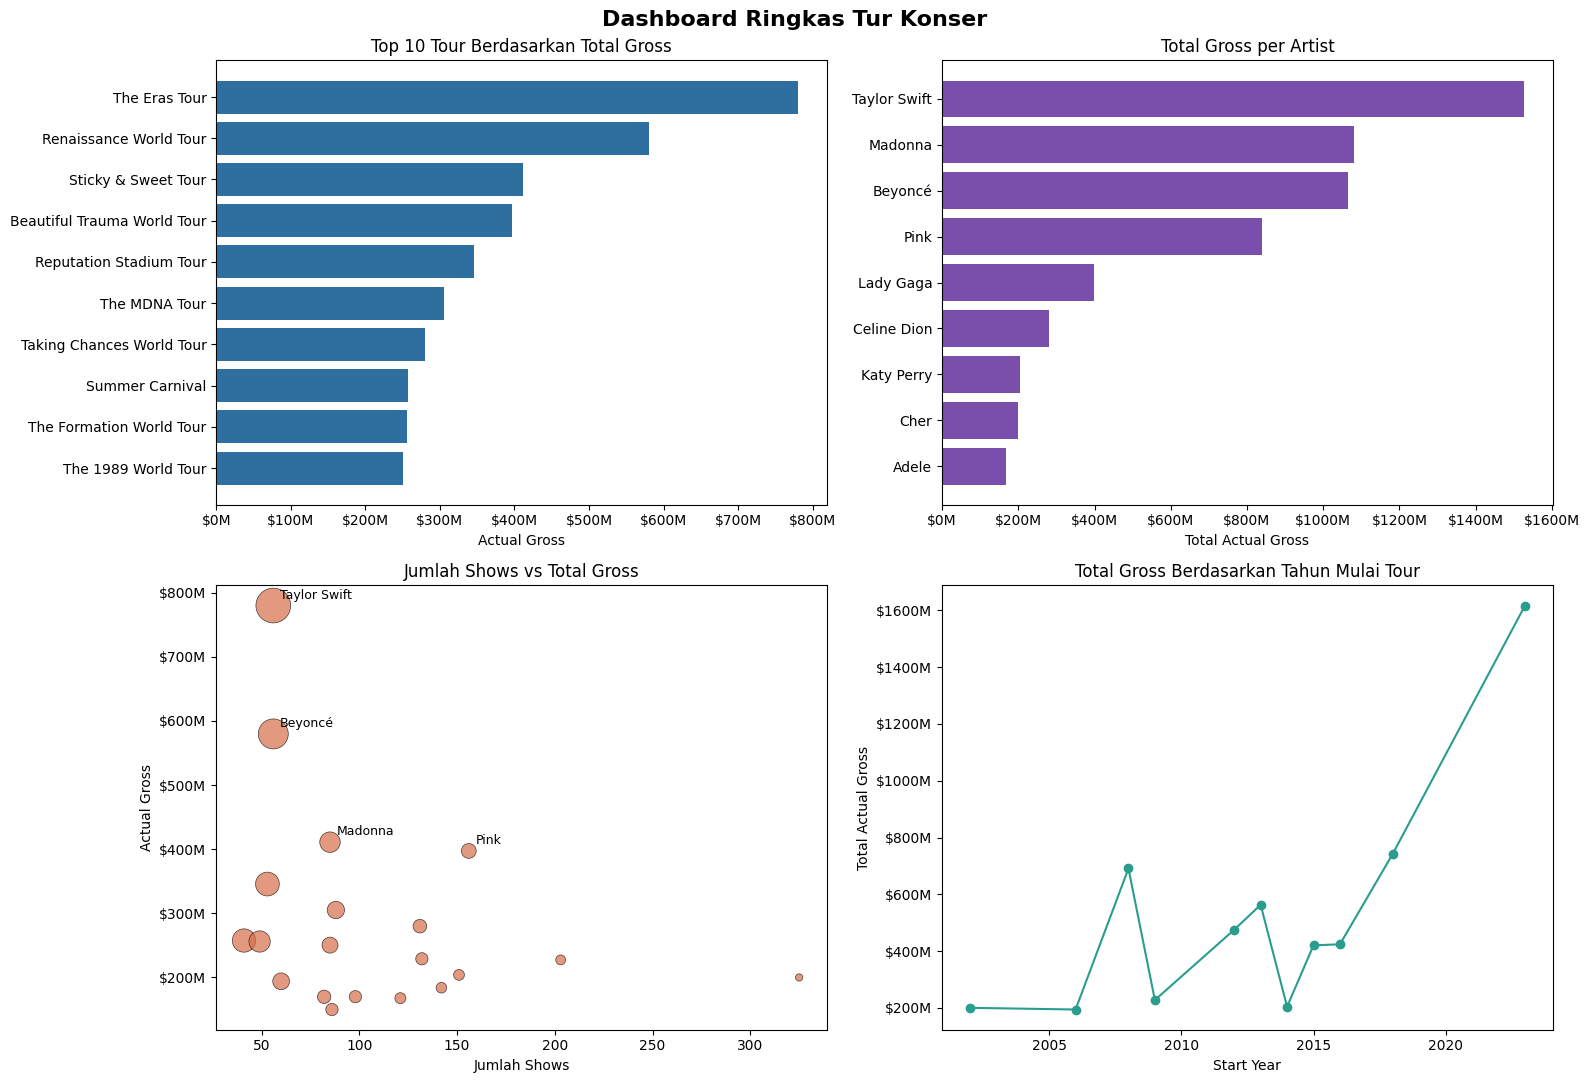

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Dashboard Ringkas Tur Konser", fontsize=16, fontweight="bold")

top_10 = plot_df.sort_values("actual_gross_usd", ascending=True).tail(10)
axes[0, 0].barh(top_10["tour_title"], top_10["actual_gross_usd"], color="#2F6F9F")
axes[0, 0].set_title("Top 10 Tour Berdasarkan Total Gross")
axes[0, 0].set_xlabel("Actual Gross")
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(usd_millions))

artist_top = artist_summary.sort_values("total_actual_gross_usd", ascending=True)
axes[0, 1].barh(artist_top["artist"], artist_top["total_actual_gross_usd"], color="#7A4EAB")
axes[0, 1].set_title("Total Gross per Artist")
axes[0, 1].set_xlabel("Total Actual Gross")
axes[0, 1].xaxis.set_major_formatter(FuncFormatter(usd_millions))

axes[1, 0].scatter(
    plot_df["shows"],
    plot_df["actual_gross_usd"],
    s=plot_df["average_gross_million"] * 45,
    alpha=0.7,
    color="#D86C4A",
    edgecolor="black",
    linewidth=0.5,
)
axes[1, 0].set_title("Jumlah Shows vs Total Gross")
axes[1, 0].set_xlabel("Jumlah Shows")
axes[1, 0].set_ylabel("Actual Gross")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(usd_millions))

for _, row in plot_df.nlargest(4, "actual_gross_usd").iterrows():
    axes[1, 0].annotate(row["artist"], (row["shows"], row["actual_gross_usd"]), xytext=(5, 5), textcoords="offset points", fontsize=9)

axes[1, 1].plot(year_summary["start_year"], year_summary["total_actual_gross_usd"], marker="o", color="#2A9D8F")
axes[1, 1].set_title("Total Gross Berdasarkan Tahun Mulai Tour")
axes[1, 1].set_xlabel("Start Year")
axes[1, 1].set_ylabel("Total Actual Gross")
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(usd_millions))

plt.tight_layout()
plt.show()

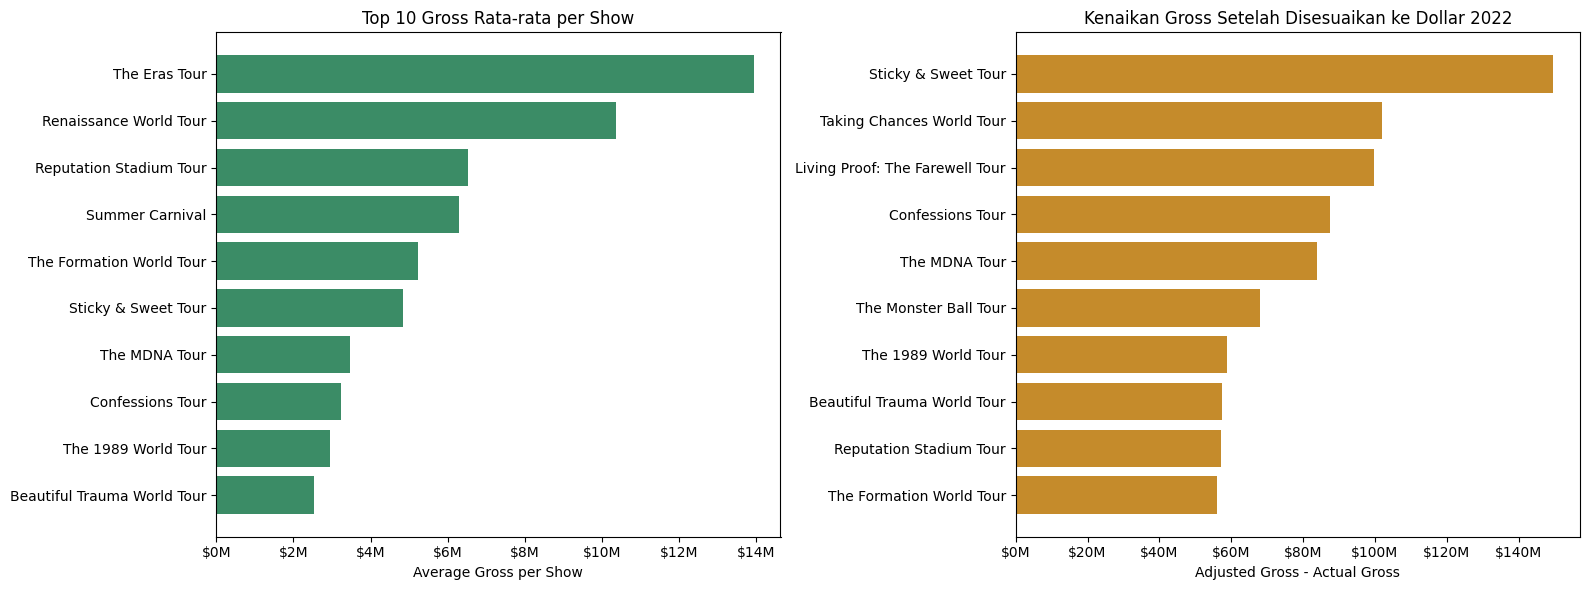

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

efficient_tours = plot_df.sort_values("average_gross_usd", ascending=True).tail(10)
axes[0].barh(efficient_tours["tour_title"], efficient_tours["average_gross_usd"], color="#3B8C66")
axes[0].set_title("Top 10 Gross Rata-rata per Show")
axes[0].set_xlabel("Average Gross per Show")
axes[0].xaxis.set_major_formatter(FuncFormatter(usd_millions))

adjustment_top = plot_df.sort_values("adjustment_gap_usd", ascending=True).tail(10)
axes[1].barh(adjustment_top["tour_title"], adjustment_top["adjustment_gap_usd"], color="#C58B2B")
axes[1].set_title("Kenaikan Gross Setelah Disesuaikan ke Dollar 2022")
axes[1].set_xlabel("Adjusted Gross - Actual Gross")
axes[1].xaxis.set_major_formatter(FuncFormatter(usd_millions))

plt.tight_layout()
plt.show()

In [58]:
corr_shows_gross = plot_df["shows"].corr(plot_df["actual_gross_usd"])
corr_avg_total = plot_df["average_gross_usd"].corr(plot_df["actual_gross_usd"])

print("Cara membaca hasil visualisasi:")
print(f"- Korelasi jumlah shows vs total gross: {corr_shows_gross:.2f}. Artinya jumlah show tidak otomatis menjamin gross paling besar.")
print(f"- Korelasi average gross per show vs total gross: {corr_avg_total:.2f}. Ini menunjukkan efisiensi per show sangat berpengaruh pada total gross.")
print("- Tour modern seperti The Eras Tour dan Renaissance World Tour sangat kuat karena gross per show-nya tinggi, meskipun jumlah show tidak sebanyak tour lama.")
print("- Tour lama seperti Living Proof punya show sangat banyak, tetapi average gross per show-nya jauh lebih rendah dibanding tour modern.")

Cara membaca hasil visualisasi:
- Korelasi jumlah shows vs total gross: -0.31. Artinya jumlah show tidak otomatis menjamin gross paling besar.
- Korelasi average gross per show vs total gross: 0.90. Ini menunjukkan efisiensi per show sangat berpengaruh pada total gross.
- Tour modern seperti The Eras Tour dan Renaissance World Tour sangat kuat karena gross per show-nya tinggi, meskipun jumlah show tidak sebanyak tour lama.
- Tour lama seperti Living Proof punya show sangat banyak, tetapi average gross per show-nya jauh lebih rendah dibanding tour modern.


## Insight Untuk Setiap Visualisasi

### 1. Top 10 Tour Berdasarkan Total Gross
- Temuan:
  The Eras Tour menjadi tur dengan actual gross tertinggi, diikuti Renaissance World Tour dan Sticky & Sweet Tour.
- Makna:
  Pendapatan terbesar terkonsentrasi pada beberapa tur papan atas; tidak semua tur dalam daftar memiliki skala pendapatan yang sama.
- Kemungkinan penyebab:
  Demand tinggi, harga tiket premium, kapasitas venue besar, dan popularitas artist saat tur berlangsung.

### 2. Total Gross per Artist
- Temuan:
  Taylor Swift menjadi artist dengan total actual gross terbesar di dataset.
- Makna:
  Dominasi Taylor Swift bukan hanya dari satu tur, tetapi dari beberapa tur besar yang konsisten masuk daftar.
- Kemungkinan penyebab:
  Basis penggemar global, strategi tur stadion, katalog album yang kuat, dan permintaan tiket yang sangat tinggi.

### 3. Jumlah Shows vs Total Gross
- Temuan:
  Jumlah show tidak selalu sejalan dengan total gross. Korelasi shows terhadap actual gross bernilai negatif lemah.
- Makna:
  Banyak show bukan jaminan menjadi tur paling menguntungkan. Gross per show lebih menentukan.
- Kemungkinan penyebab:
  Perbedaan harga tiket, kapasitas venue, era tur, negara/kota yang dikunjungi, dan daya beli penonton.

### 4. Total Gross Berdasarkan Tahun Mulai Tour
- Temuan:
  Tahun-tahun terbaru, terutama 2023, terlihat sangat kuat karena ada tur besar seperti The Eras Tour dan Renaissance World Tour.
- Makna:
  Pasar konser modern menghasilkan gross yang jauh lebih tinggi dibanding banyak tur lama.
- Kemungkinan penyebab:
  Inflasi harga tiket, venue lebih besar, sistem penjualan tiket modern, dan meningkatnya demand konser pascapandemi.

### 5. Top 10 Gross Rata-rata per Show
- Temuan:
  The Eras Tour memiliki gross per show tertinggi, disusul Renaissance World Tour.
- Makna:
  Efisiensi pendapatan per konser sangat tinggi pada tur modern tertentu.
- Kemungkinan penyebab:
  Tiket premium, stadion besar, banyak show sold out, dan tingginya willingness to pay dari penonton.

### 6. Kenaikan Gross Setelah Disesuaikan ke Dollar 2022
- Temuan:
  Beberapa tur lama mengalami kenaikan besar setelah gross disesuaikan ke nilai dollar 2022.
- Makna:
  Perbandingan actual gross saja kurang adil untuk tur lintas era; adjusted gross membantu membaca nilai historis.
- Kemungkinan penyebab:
  Inflasi, perubahan harga tiket, dan perbedaan nilai uang antara tahun tur lama dan 2022.

### 7. Correlation Matrix
- Temuan:
  Average gross per show memiliki hubungan paling kuat dengan actual gross, sedangkan jumlah shows tidak menunjukkan hubungan positif kuat.
- Makna:
  Kualitas pendapatan per show lebih penting daripada sekadar kuantitas show.
- Kemungkinan penyebab:
  Tur dengan sedikit show tetapi harga tiket dan kapasitas venue tinggi dapat mengalahkan tur dengan show lebih banyak.

## Kesimpulan Akhir Project

In [59]:
highest_gross_tour = df_eda.loc[df_eda["actual_gross_usd"].idxmax()]
dominant_artist = artist_summary.iloc[0]
best_average_tour = df_eda.loc[df_eda["gross_per_show"].idxmax()]
shows_gross_corr = df_eda["shows"].corr(df_eda["actual_gross_usd"])

print("Kesimpulan akhir project:")
print(f"1. Tour dengan gross tertinggi adalah {highest_gross_tour['tour_title']} oleh {highest_gross_tour['artist']} dengan actual gross ${highest_gross_tour['actual_gross_usd']:,.0f}.")
print(f"2. Artist paling dominan adalah {dominant_artist['artist']} dengan total actual gross ${dominant_artist['total_actual_gross_usd']:,.0f}.")
print(f"3. Jumlah shows tidak selalu menentukan gross tertinggi. Korelasi shows dan actual gross adalah {shows_gross_corr:.2f}.")
print(f"4. Tour dengan average gross terbaik adalah {best_average_tour['tour_title']} oleh {best_average_tour['artist']} dengan gross per show ${best_average_tour['gross_per_show']:,.0f}.")
print("5. Saran analisis lanjutan: tambahkan data harga tiket rata-rata, kapasitas venue, negara/kota tur, jumlah penonton, dan periode penjualan tiket agar faktor penyebab gross tinggi bisa dianalisis lebih dalam.")

Kesimpulan akhir project:
1. Tour dengan gross tertinggi adalah The Eras Tour oleh Taylor Swift dengan actual gross $780,000,000.
2. Artist paling dominan adalah Taylor Swift dengan total actual gross $1,526,075,146.
3. Jumlah shows tidak selalu menentukan gross tertinggi. Korelasi shows dan actual gross adalah -0.31.
4. Tour dengan average gross terbaik adalah The Eras Tour oleh Taylor Swift dengan gross per show $13,928,571.
5. Saran analisis lanjutan: tambahkan data harga tiket rata-rata, kapasitas venue, negara/kota tur, jumlah penonton, dan periode penjualan tiket agar faktor penyebab gross tinggi bisa dianalisis lebih dalam.
